## Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import joblib

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from rdkit_and_test_functions import smiles_to_3d,extract_3d_features,prepare_test_data

In [2]:
X_train = joblib.load("X_train.pkl")
y_train = joblib.load("y_train.pkl")

## RBF SVR

In [3]:
svr_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.1
    ))
])

svr_rbf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svr', SVR(C=100))])

In [4]:
X_test, y_test, test_smiles = prepare_test_data(
    X_train.columns
)

X column names:
smiles

y column name:
electrochemical_gap
X_test shape: (212, 11)
y_test shape: (212,)


In [5]:
y_pred = svr_rbf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("HOPV15 Results")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

HOPV15 Results
----------------
MAE : 0.463263766160513
RMSE: 0.5974392741732402
R²  : -2.0745196647206137


In [8]:
results = pd.DataFrame({
    "SMILES": test_smiles,
    "Experimental_Gap": y_test,
    "Predicted_Gap": y_pred,
    "Absolute_Error": np.abs(y_test - y_pred)
})

results.to_csv("HOPV15_predictions_rbf_svr.csv", index=False)

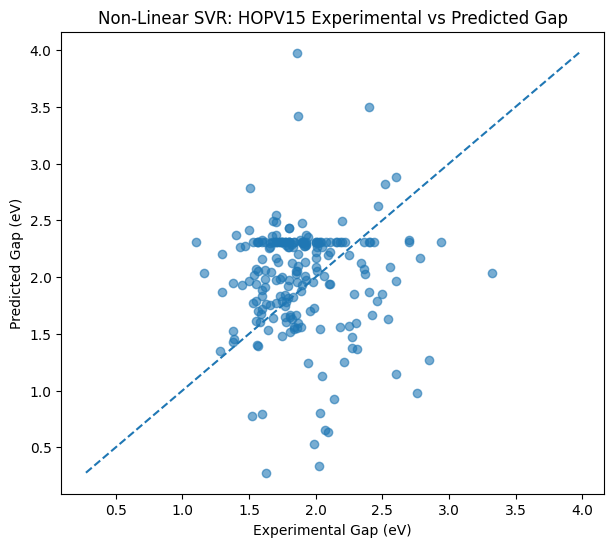

In [9]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Experimental Gap (eV)")
plt.ylabel("Predicted Gap (eV)")
plt.title("Non-Linear SVR: HOPV15 Experimental vs Predicted Gap")

plt.show()